In [1]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


inspection_id = "0AP3OOMEPID" #fhr13-01
angle_profiles = ["0"]
num_tracks = 22
run_number = 10
results_dir = f"/mnt/f/data-files/{inspection_id}/track_runs/dent_ultrasound/"


In [2]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [3]:
len(data_files)

50873

In [4]:

df = pd.read_parquet(data_files[-1000])
#remove attn_map columns
df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
df.head()
#13488222

,inspection_id,clip_id,track_id,frame_idx,timer_tick,odometer_tick,dent_prob
0,0AP3OOMEPID,01-023-18AJ0NXL,23,55950000,2011630651,1018855441,0.000938
1,0AP3OOMEPID,01-023-18AJ0NXL,23,55950001,2011630690,1018855459,0.000938
2,0AP3OOMEPID,01-023-18AJ0NXL,23,55950002,2011630728,1018855477,0.000938
3,0AP3OOMEPID,01-023-18AJ0NXL,23,55950003,2011630768,1018855495,0.000938
4,0AP3OOMEPID,01-023-18AJ0NXL,23,55950004,2011630808,1018855513,0.000938


In [5]:
def keep_confident(df, threshold=0.5, score_col='dent_prob'):
    """
    Keep only rows where crack_score is greater than the given threshold.
    """
    return df[df[score_col] > threshold].reset_index(drop=True)

## Create a DataFrame for each profile and track and range
def create_df(track_idx, threshold = 0.7, frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx:02d}"]
    else:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx:02d}" and f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_parquet(path)
        df = keep_confident(df, threshold=threshold, score_col='dent_prob')
        df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [6]:
def analyze_frame_sequences(df, frame_col='frame_idx', range_col='frame_range', plot=True):
    """
    Analyze consecutive frame sequences in a DataFrame.
    
    Args:
        df: DataFrame with frame indices
        frame_col: column name containing frame indices
        range_col: name for the new range column
        plot: whether to show histogram of sequence lengths
    
    Returns:
        tuple: (df_with_ranges, num_unique_sequences, sequence_lengths)
    """
    if len(df) == 0:
        print("Empty DataFrame")
        return df.copy(), 0, []
    
    # # Sort by frame index and reset index
    # df_sorted = df.copy().sort_values(frame_col).reset_index(drop=True) #aleardy sorted
    df_sorted = df.copy()
    
    
    # Find breaks in consecutive sequences
    frame_diff = df_sorted[frame_col].diff()
    breaks = (frame_diff != 1) & (frame_diff.notna())
    
    # Assign range IDs - each break starts a new range
    range_ids = breaks.cumsum()
    
    # Create range labels and calculate sequence lengths
    range_labels = []
    sequence_lengths = []
    
    for range_id in range_ids.unique():
        mask = range_ids == range_id
        start_frame = df_sorted.loc[mask, frame_col].min()
        end_frame = df_sorted.loc[mask, frame_col].max()
        sequence_length = end_frame - start_frame + 1
        
        range_labels.append(f"{start_frame}_{end_frame}")
        sequence_lengths.append(sequence_length)
    
    # Map range IDs to labels
    range_mapping = dict(zip(range_ids.unique(), range_labels))
    df_sorted[range_col] = range_ids.map(range_mapping)
    
    # Number of unique sequences
    num_unique_sequences = len(range_labels)
    
    # Print summary
    print(f"Total frames: {len(df_sorted)}")
    print(f"Number of unique sequences: {num_unique_sequences}")
    print(f"Sequence lengths - Min: {min(sequence_lengths)}, Max: {max(sequence_lengths)}, Mean: {np.mean(sequence_lengths):.1f}")
    
    # Plot histogram if requested
    if plot:
        plt.figure(figsize=(10, 6))
        plt.hist(sequence_lengths, bins=max(1, min(50, num_unique_sequences//2)), 
                 color='skyblue', alpha=0.7, edgecolor='black')
        plt.title('Histogram of Consecutive Frame Sequence Lengths')
        plt.xlabel('Sequence Length (number of consecutive frames)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        # Add statistics text
        plt.text(0.7, 0.9, f'Total sequences: {num_unique_sequences}\n'
                           f'Mean length: {np.mean(sequence_lengths):.1f}\n'
                           f'Max length: {max(sequence_lengths)}', 
                 transform=plt.gca().transAxes, 
                 bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    return df_sorted, num_unique_sequences, sequence_lengths

In [7]:
def merge_sequences_to_single_row(df_with_ranges, range_col='frame_range', inspection_id=None):
    """
    Merge rows by sequence to have one row per frame_range sequence.
    
    Args:
        df_with_ranges: DataFrame with frame_range column and detection data
        range_col: column name containing frame range identifiers
        inspection_id: inspection ID to add to the output (if not in df)
    
    Returns:
        DataFrame with one row per sequence containing aggregated information
    """
    if len(df_with_ranges) == 0:
        return pd.DataFrame()
    
    # Group by frame_range and aggregate
    agg_dict = {
        'frame_idx': ['min', 'max', 'count'],
        'dent_prob': ['mean', 'max', 'min', 'std'],
        'timer_tick': ['min', 'max'],
        'odometer_tick': ['min', 'max'],
        'clip_id': 'first',
        'track_id': 'first'
    }
    
    # Add inspection_id if it exists in the dataframe
    if 'inspection_id' in df_with_ranges.columns:
        agg_dict['inspection_id'] = 'first'
    
    sequence_summary = df_with_ranges.groupby(range_col).agg(agg_dict).round(4)
    
    # Flatten column names
    sequence_summary.columns = [f'{col[0]}_{col[1]}' if col[1] != '' else col[0] 
                               for col in sequence_summary.columns]
    
    # Reset index to make frame_range a regular column
    sequence_summary = sequence_summary.reset_index()
    
    # Add computed columns
    sequence_summary['sequence_length'] = sequence_summary['frame_idx_count']
    sequence_summary['frame_span'] = (sequence_summary['frame_idx_max'] - 
                                     sequence_summary['frame_idx_min'] + 1)
    sequence_summary['timer_span'] = (sequence_summary['timer_tick_max'] - 
                                     sequence_summary['timer_tick_min'])
    sequence_summary['odometer_span'] = (sequence_summary['odometer_tick_max'] - 
                                        sequence_summary['odometer_tick_min'])
    
    # Rename columns for clarity
    column_rename = {
        'frame_idx_min': 'start_frame',
        'frame_idx_max': 'end_frame', 
        'frame_idx_count': 'num_detections',
        'dent_prob_mean': 'avg_confidence',
        'dent_prob_max': 'max_confidence',
        'dent_prob_min': 'min_confidence',
        'dent_prob_std': 'confidence_std',
        'timer_tick_min': 'start_timer_tick',
        'timer_tick_max': 'end_timer_tick',
        'odometer_tick_min': 'start_odometer_tick',
        'odometer_tick_max': 'end_odometer_tick',
        'clip_id_first': 'clip_id',
        'track_id_first': 'track_id'
    }
    
    # Add inspection_id rename if it exists
    if 'inspection_id_first' in sequence_summary.columns:
        column_rename['inspection_id_first'] = 'inspection_id'
    
    sequence_summary = sequence_summary.rename(columns=column_rename)
    
    # Add inspection_id if provided and not in dataframe
    if inspection_id and 'inspection_id' not in sequence_summary.columns:
        sequence_summary['inspection_id'] = inspection_id
    
    # Reorder columns for better readability
    column_order = [
        'inspection_id', 'frame_range', 'clip_id', 'track_id',
        'start_frame', 'end_frame', 'sequence_length', 'frame_span', 'num_detections',
        'start_timer_tick', 'end_timer_tick', 'timer_span',
        'start_odometer_tick', 'end_odometer_tick', 'odometer_span',
        'avg_confidence', 'max_confidence', 'min_confidence', 'confidence_std'
    ]
    
    # Only keep columns that exist
    available_columns = [col for col in column_order if col in sequence_summary.columns]
    sequence_summary = sequence_summary[available_columns]
    
    print(f"Merged {len(df_with_ranges)} rows into {len(sequence_summary)} sequences")
    
    return sequence_summary

In [8]:
from io import BytesIO

def save_df_to_s3_parquet(df, bucket_name, s3_key):
    """
    Save DataFrame to S3 as parquet file
    
    Args:
        df: DataFrame to save
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
    """
    # Convert DataFrame to parquet in memory
    parquet_buffer = BytesIO()
    df.to_parquet(parquet_buffer, index=False)
    parquet_buffer.seek(0)
    
    # Upload to S3
    s3_client = boto3.client('s3')
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=parquet_buffer.getvalue(),
        ContentType='application/octet-stream'
    )
    
    print(f"DataFrame saved to s3://{bucket_name}/{s3_key}")

Total frames: 123644
Number of unique sequences: 1373
Sequence lengths - Min: 1, Max: 2490, Mean: 90.1


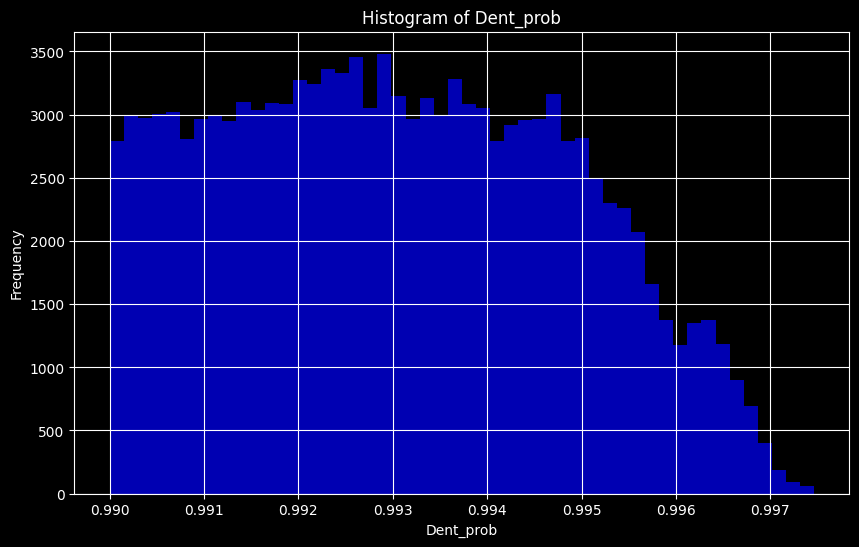

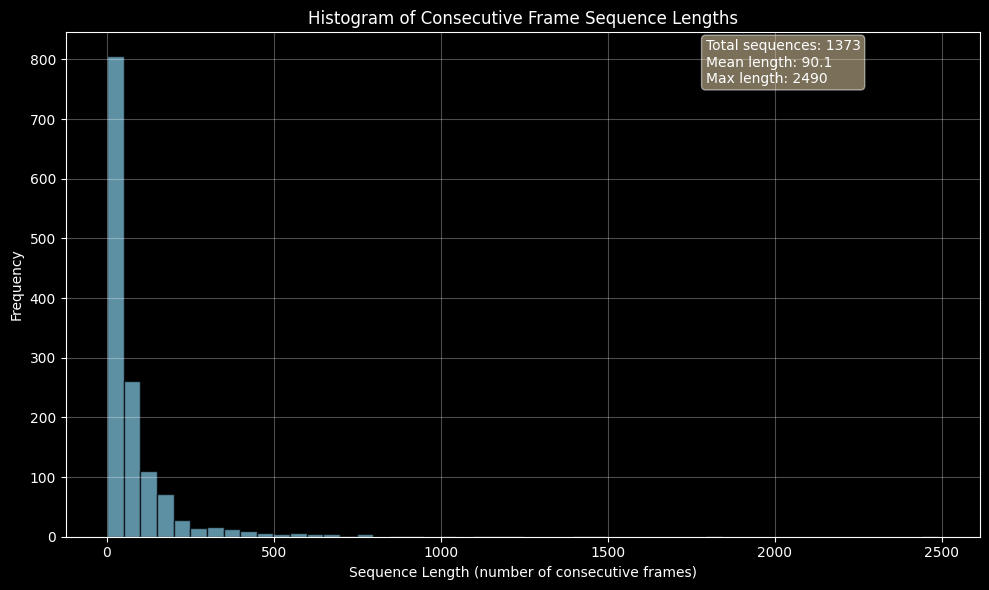

Merged 123644 rows into 1373 sequences
1373

Sequence Summary for track 0 and threshold 0.99:
Total sequences: 1373
Average sequence length: 90.1
Longest sequence: 2490 frames
Average confidence: 0.992
1373
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_0.parquet
Total frames: 196250
Number of unique sequences: 1750
Sequence lengths - Min: 1, Max: 2970, Mean: 112.1


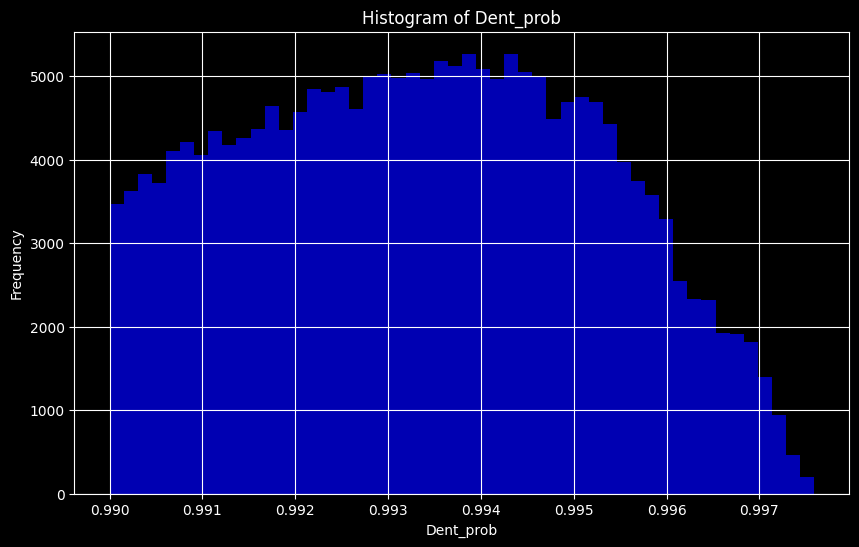

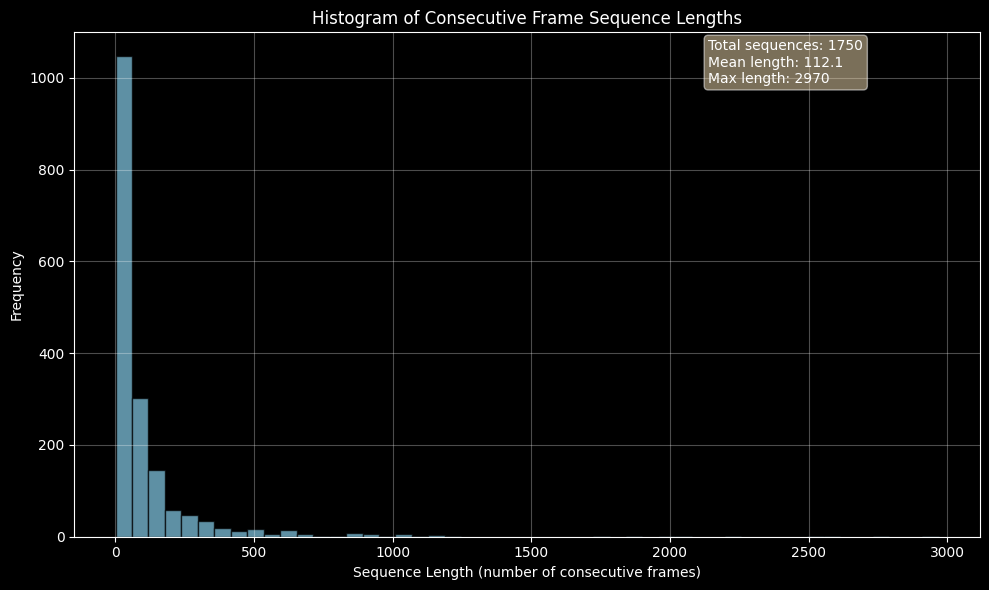

Merged 196250 rows into 1750 sequences
1750

Sequence Summary for track 1 and threshold 0.99:
Total sequences: 1750
Average sequence length: 112.1
Longest sequence: 2970 frames
Average confidence: 0.992
1750
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_1.parquet
Total frames: 149087
Number of unique sequences: 1418
Sequence lengths - Min: 1, Max: 3300, Mean: 105.1


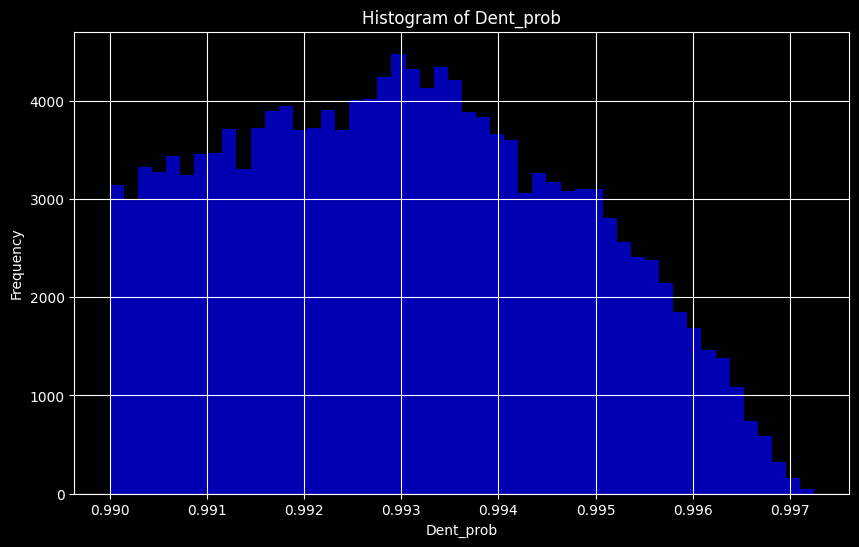

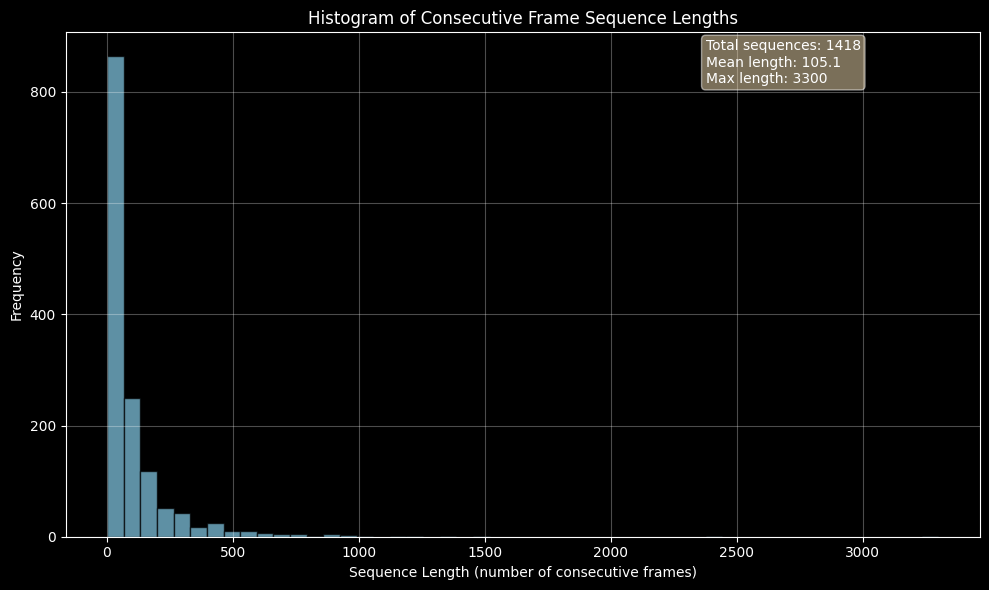

Merged 149087 rows into 1418 sequences
1418

Sequence Summary for track 2 and threshold 0.99:
Total sequences: 1418
Average sequence length: 105.1
Longest sequence: 3300 frames
Average confidence: 0.992
1418
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_2.parquet
Total frames: 117384
Number of unique sequences: 1297
Sequence lengths - Min: 1, Max: 3920, Mean: 90.5


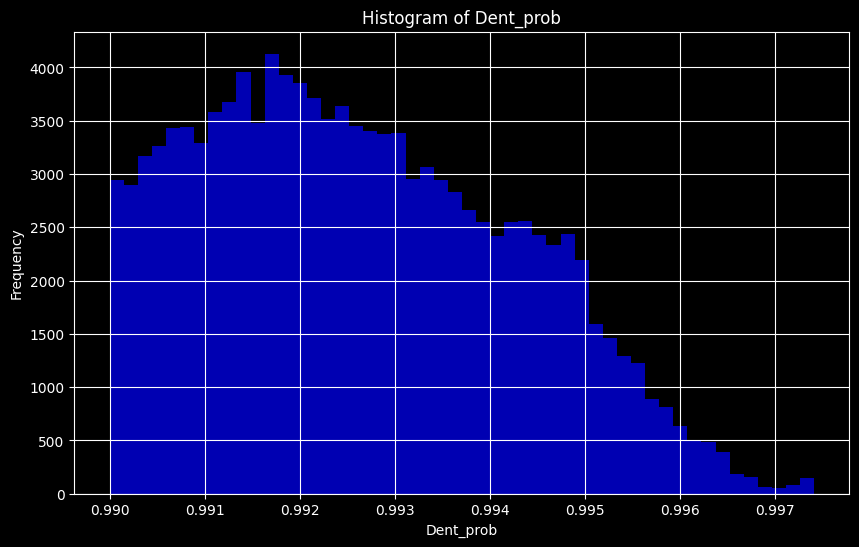

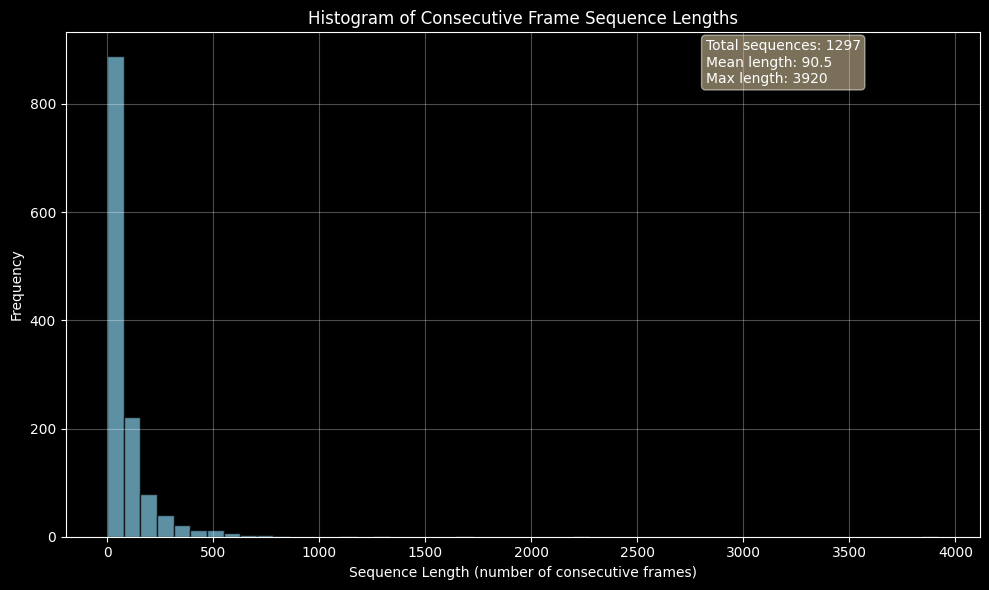

Merged 117384 rows into 1297 sequences
1297

Sequence Summary for track 3 and threshold 0.99:
Total sequences: 1297
Average sequence length: 90.5
Longest sequence: 3920 frames
Average confidence: 0.992
1297
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_3.parquet
Total frames: 146872
Number of unique sequences: 1463
Sequence lengths - Min: 1, Max: 4325, Mean: 100.4


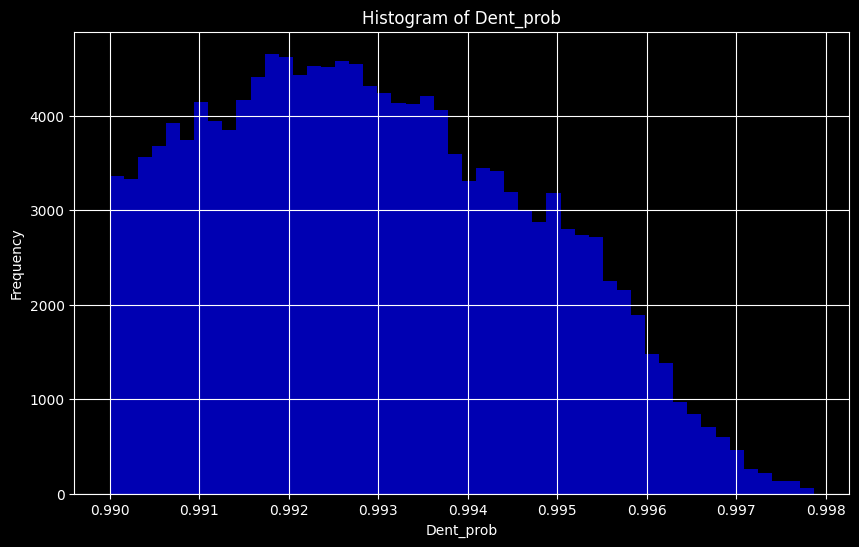

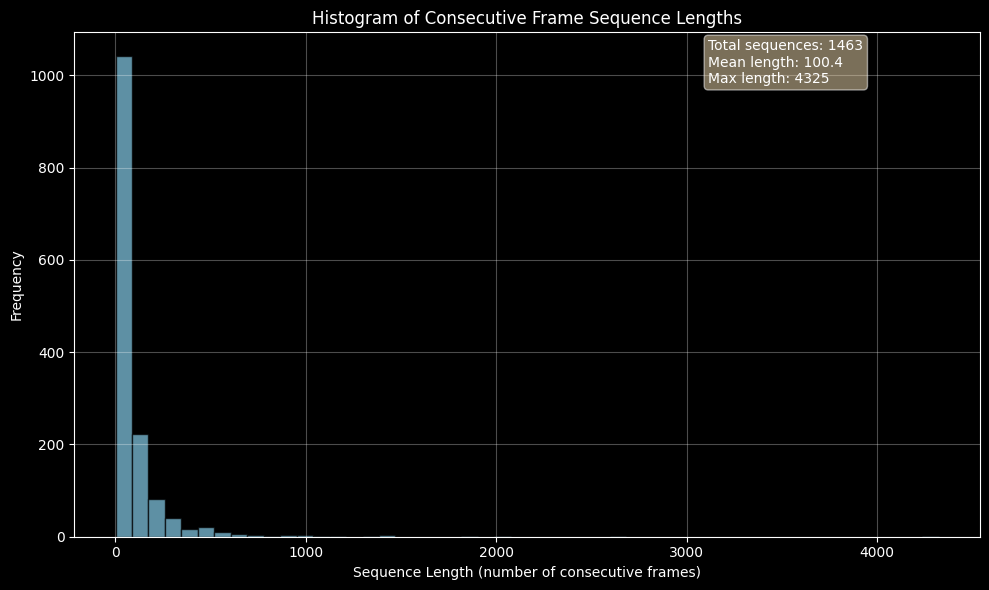

Merged 146872 rows into 1463 sequences
1463

Sequence Summary for track 4 and threshold 0.99:
Total sequences: 1463
Average sequence length: 100.4
Longest sequence: 4325 frames
Average confidence: 0.992
1463
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_4.parquet
Total frames: 232412
Number of unique sequences: 2043
Sequence lengths - Min: 1, Max: 3840, Mean: 113.8


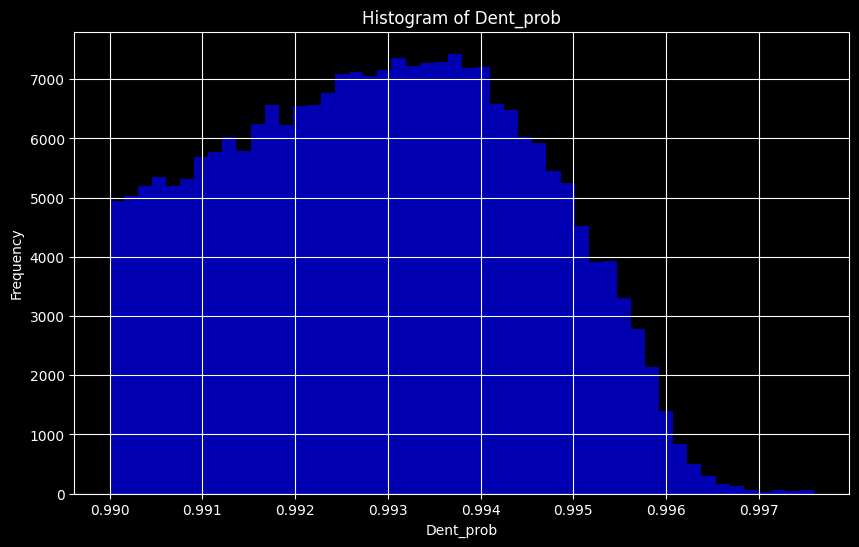

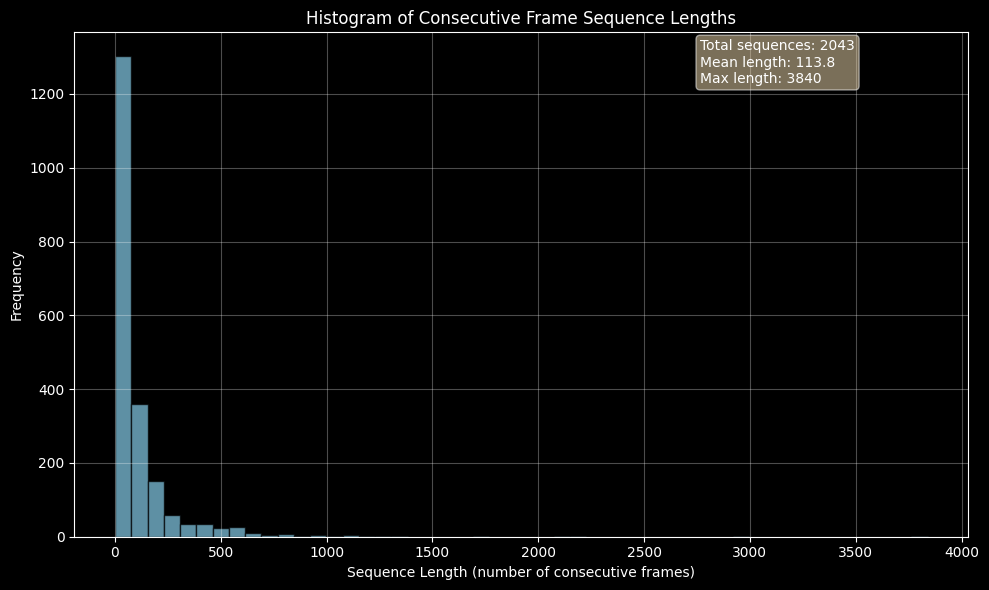

Merged 232412 rows into 2043 sequences
2043

Sequence Summary for track 5 and threshold 0.99:
Total sequences: 2043
Average sequence length: 113.8
Longest sequence: 3840 frames
Average confidence: 0.992
2043
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_5.parquet
Total frames: 171080
Number of unique sequences: 1743
Sequence lengths - Min: 1, Max: 2550, Mean: 98.2


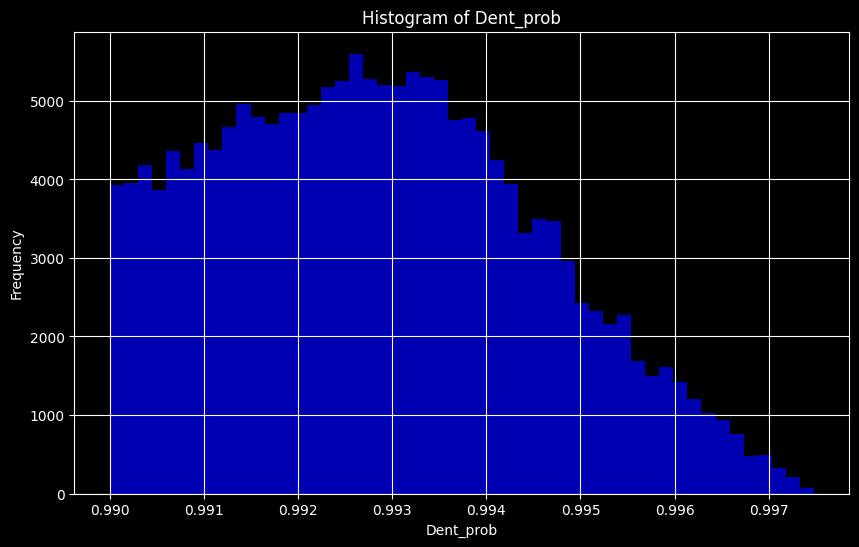

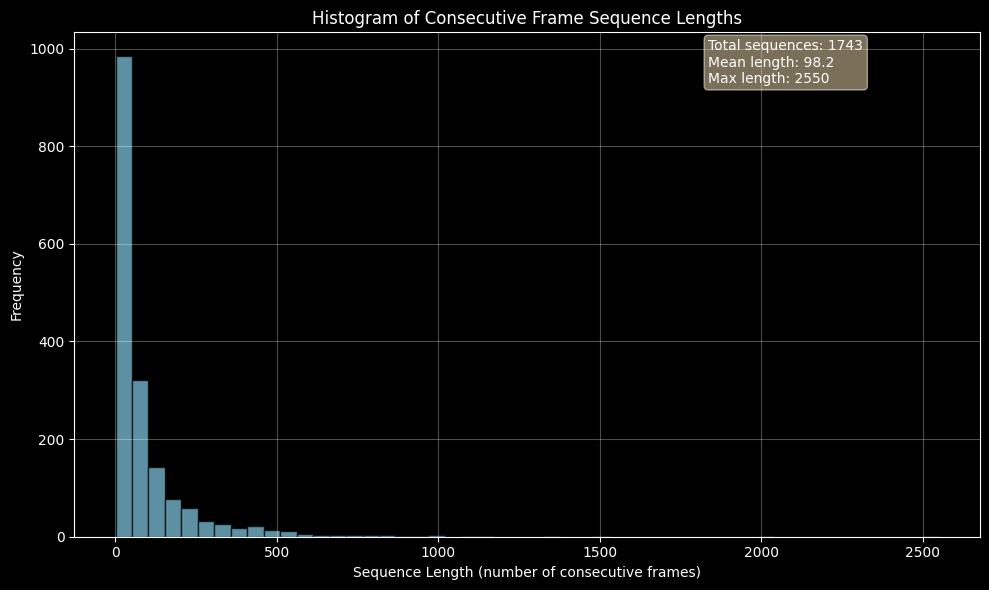

Merged 171080 rows into 1743 sequences
1743

Sequence Summary for track 6 and threshold 0.99:
Total sequences: 1743
Average sequence length: 98.2
Longest sequence: 2550 frames
Average confidence: 0.992
1743
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_6.parquet
Total frames: 12942
Number of unique sequences: 1036
Sequence lengths - Min: 1, Max: 50, Mean: 12.5


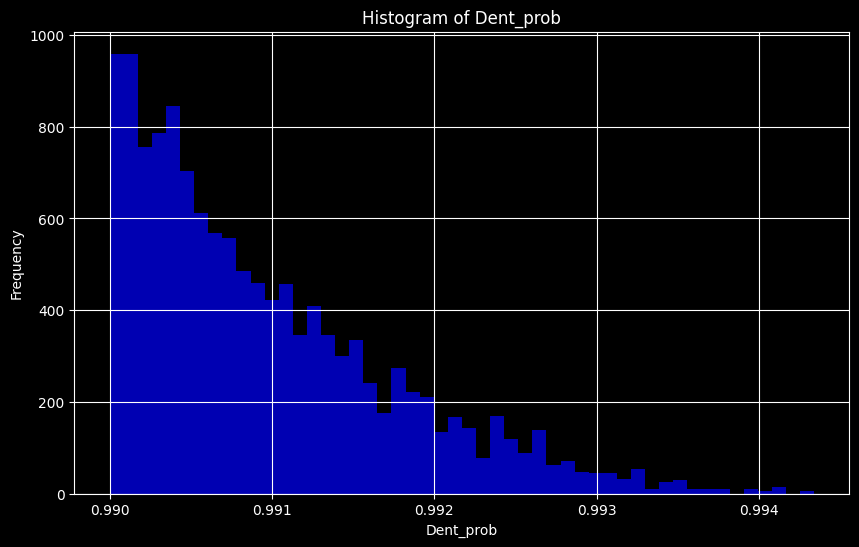

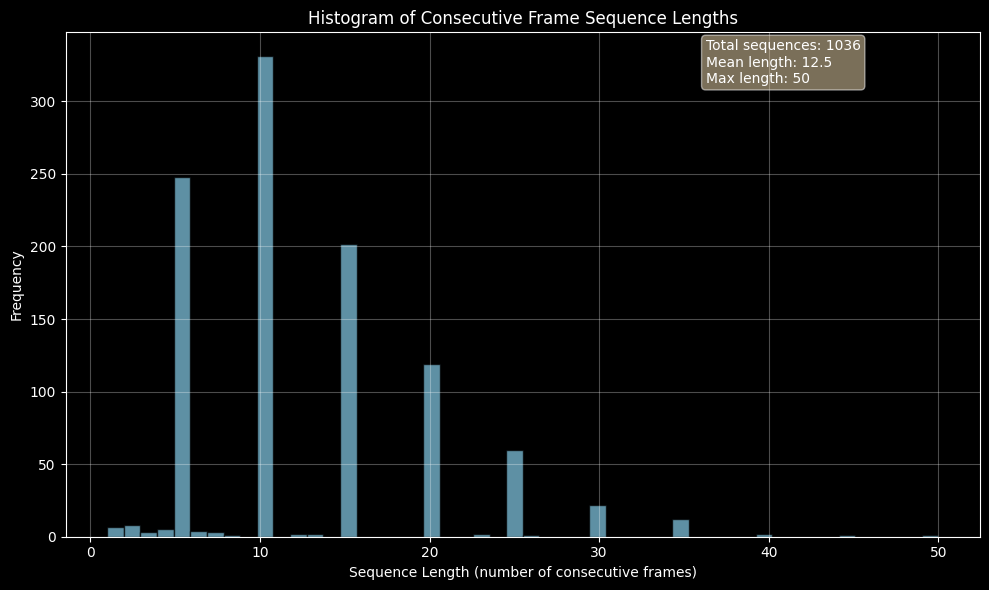

Merged 12942 rows into 1036 sequences
1036

Sequence Summary for track 7 and threshold 0.99:
Total sequences: 1036
Average sequence length: 12.5
Longest sequence: 50 frames
Average confidence: 0.991
1036
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_7.parquet
Total frames: 424459
Number of unique sequences: 4871
Sequence lengths - Min: 1, Max: 2730, Mean: 87.1


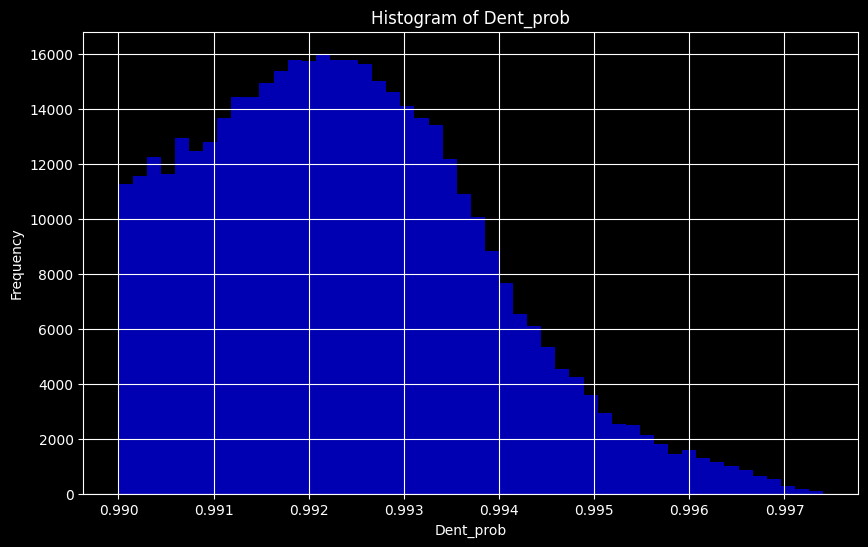

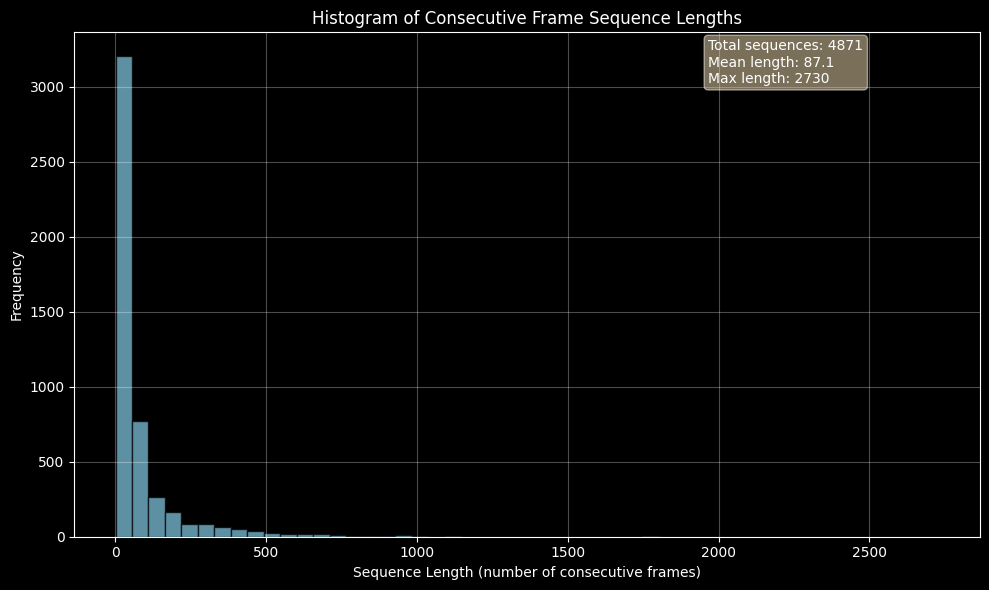

Merged 424459 rows into 4871 sequences
4871

Sequence Summary for track 8 and threshold 0.99:
Total sequences: 4871
Average sequence length: 87.1
Longest sequence: 2730 frames
Average confidence: 0.991
4871
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_8.parquet
Total frames: 648339
Number of unique sequences: 5391
Sequence lengths - Min: 1, Max: 3085, Mean: 120.3


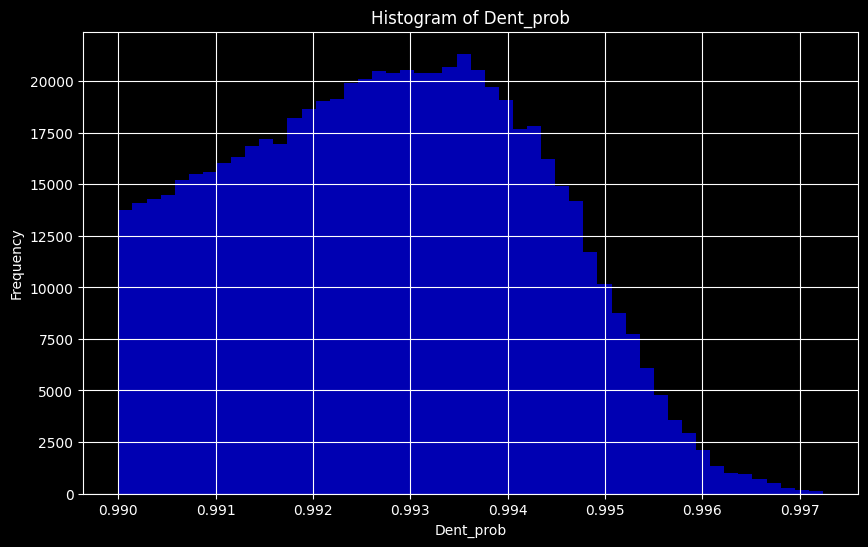

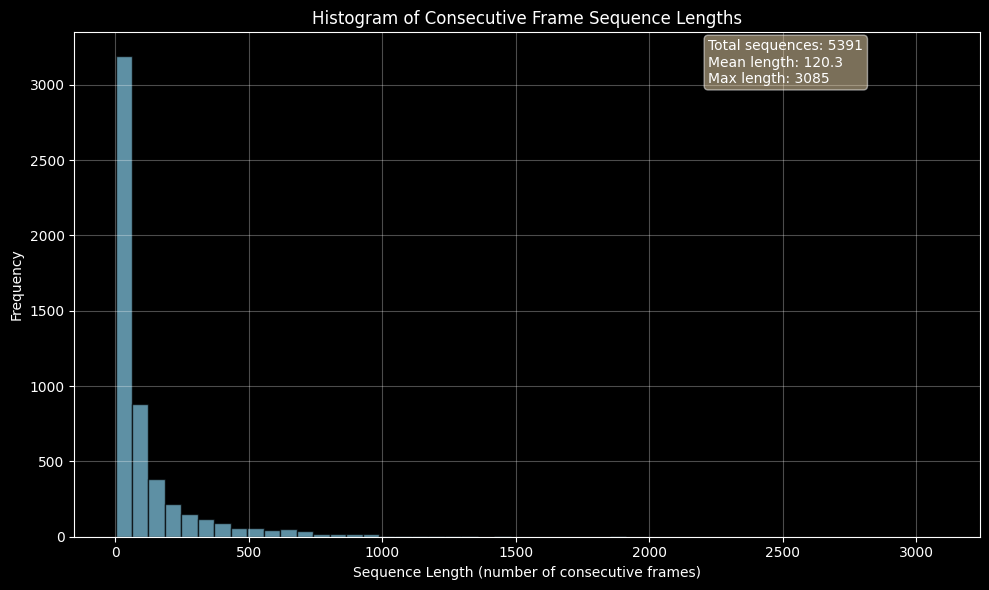

Merged 648339 rows into 5391 sequences
5391

Sequence Summary for track 9 and threshold 0.99:
Total sequences: 5391
Average sequence length: 120.3
Longest sequence: 3085 frames
Average confidence: 0.992
5391
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_9.parquet
Total frames: 204598
Number of unique sequences: 2046
Sequence lengths - Min: 1, Max: 3825, Mean: 100.0


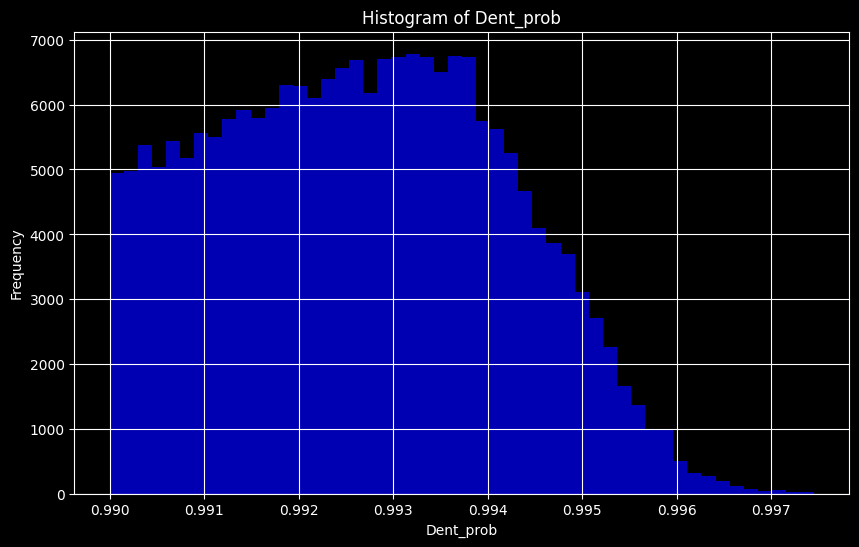

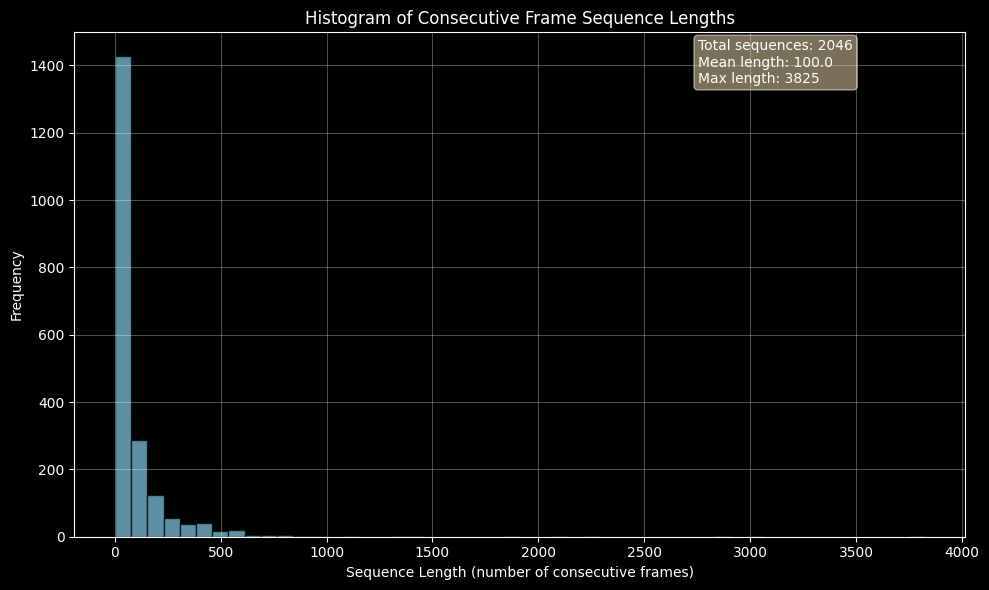

Merged 204598 rows into 2046 sequences
2046

Sequence Summary for track 10 and threshold 0.99:
Total sequences: 2046
Average sequence length: 100.0
Longest sequence: 3825 frames
Average confidence: 0.992
2046
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_10.parquet
Total frames: 176920
Number of unique sequences: 1852
Sequence lengths - Min: 1, Max: 2695, Mean: 95.5


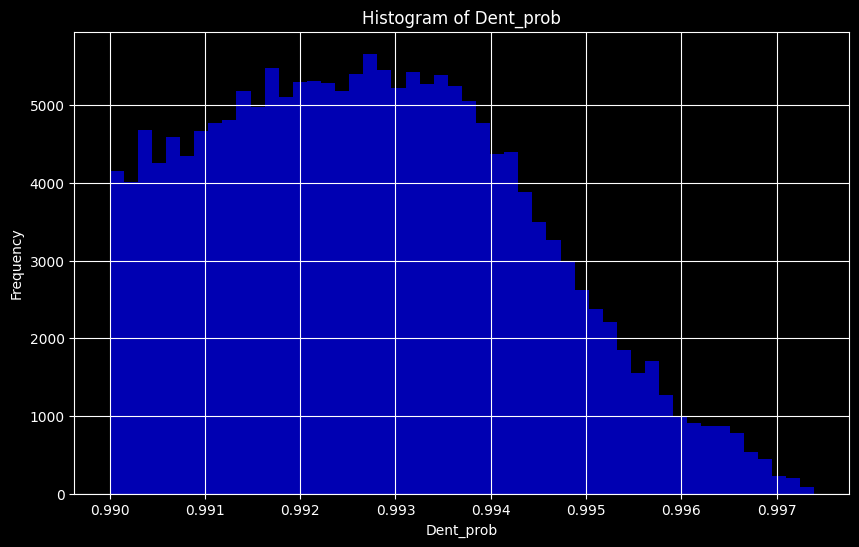

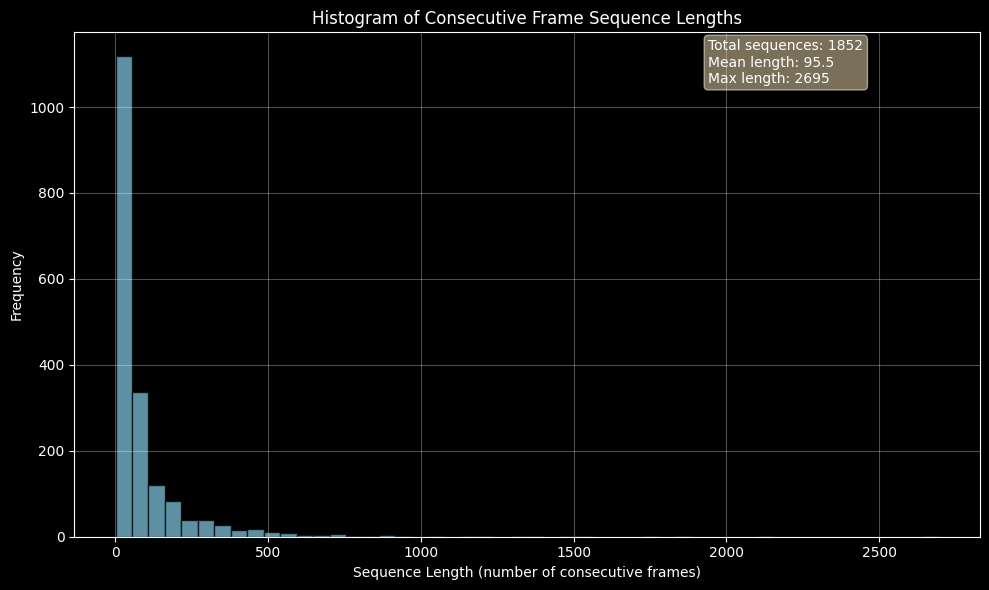

Merged 176920 rows into 1852 sequences
1852

Sequence Summary for track 11 and threshold 0.99:
Total sequences: 1852
Average sequence length: 95.5
Longest sequence: 2695 frames
Average confidence: 0.992
1852
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_11.parquet
Total frames: 152468
Number of unique sequences: 2114
Sequence lengths - Min: 1, Max: 2020, Mean: 72.1


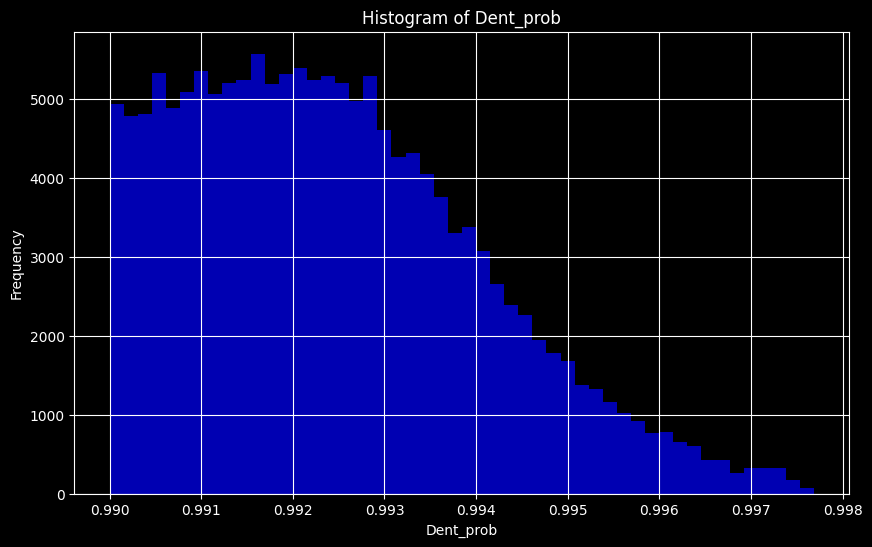

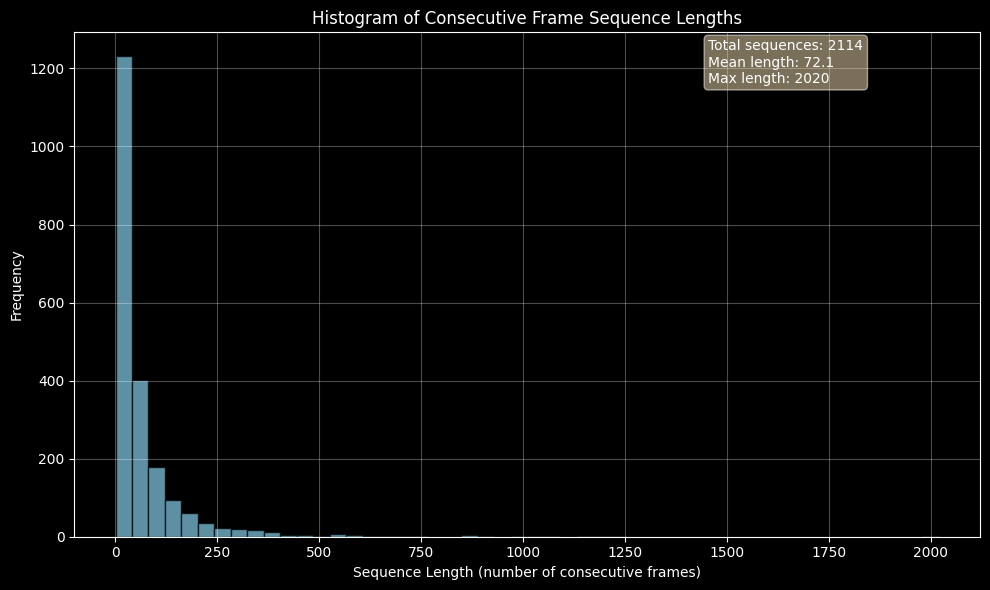

Merged 152468 rows into 2114 sequences
2114

Sequence Summary for track 12 and threshold 0.99:
Total sequences: 2114
Average sequence length: 72.1
Longest sequence: 2020 frames
Average confidence: 0.992
2114
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_12.parquet
Total frames: 164423
Number of unique sequences: 2274
Sequence lengths - Min: 1, Max: 3250, Mean: 72.3


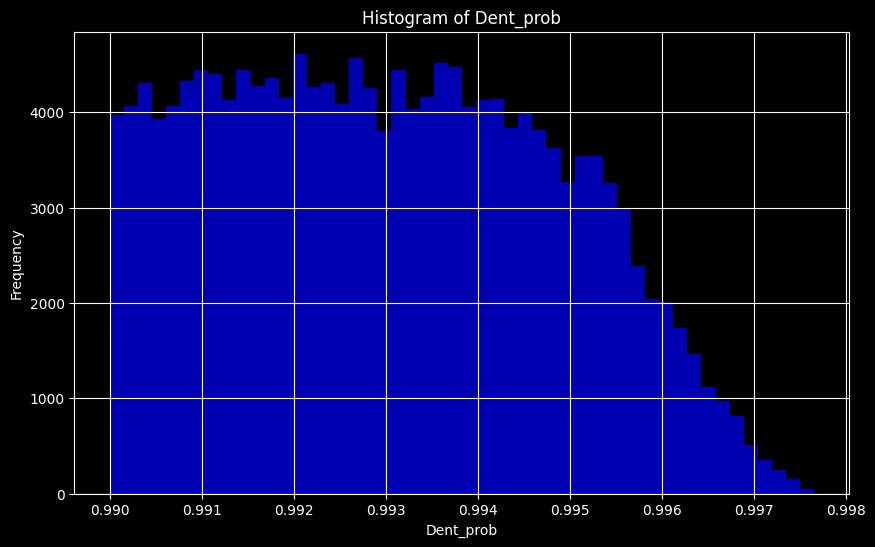

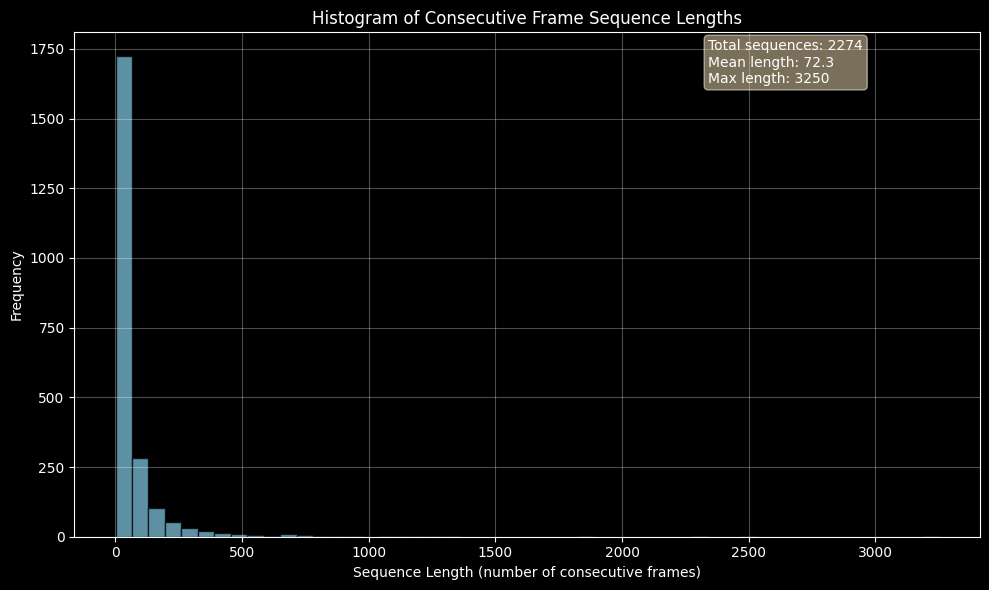

Merged 164423 rows into 2274 sequences
2274

Sequence Summary for track 13 and threshold 0.99:
Total sequences: 2274
Average sequence length: 72.3
Longest sequence: 3250 frames
Average confidence: 0.992
2274
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_13.parquet
Total frames: 375105
Number of unique sequences: 2543
Sequence lengths - Min: 1, Max: 2285, Mean: 147.5


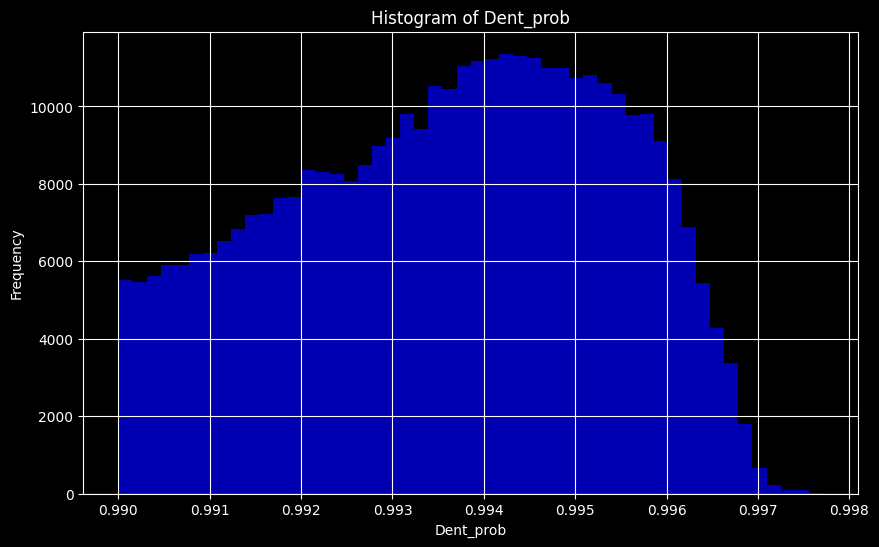

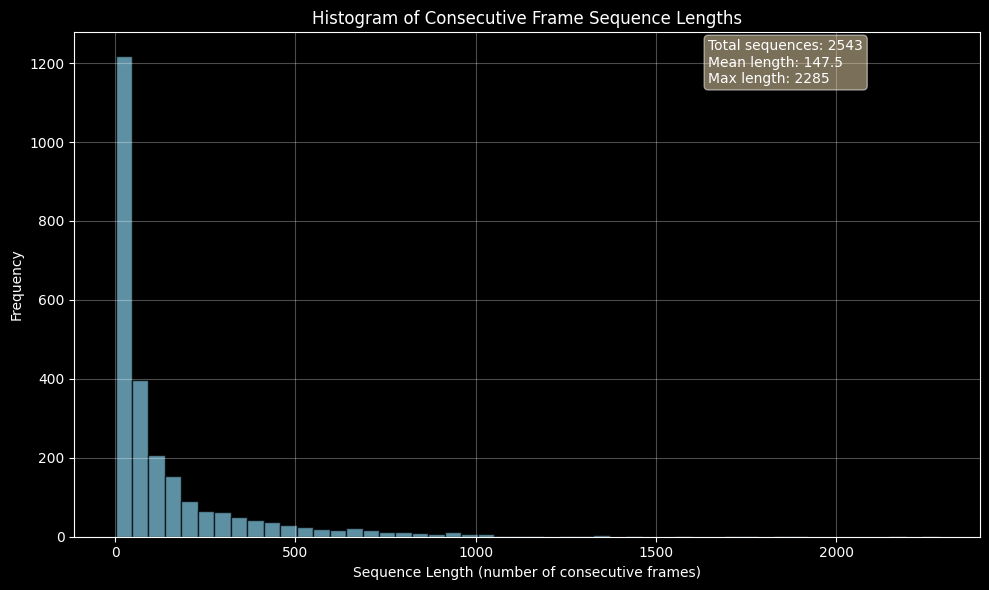

Merged 375105 rows into 2543 sequences
2543

Sequence Summary for track 14 and threshold 0.99:
Total sequences: 2543
Average sequence length: 147.5
Longest sequence: 2285 frames
Average confidence: 0.992
2543
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_14.parquet
Total frames: 189269
Number of unique sequences: 1714
Sequence lengths - Min: 1, Max: 3180, Mean: 110.4


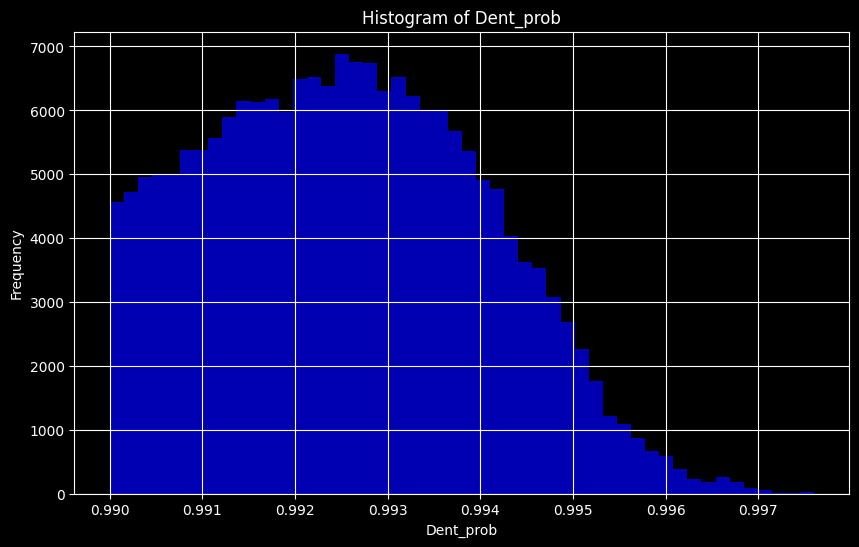

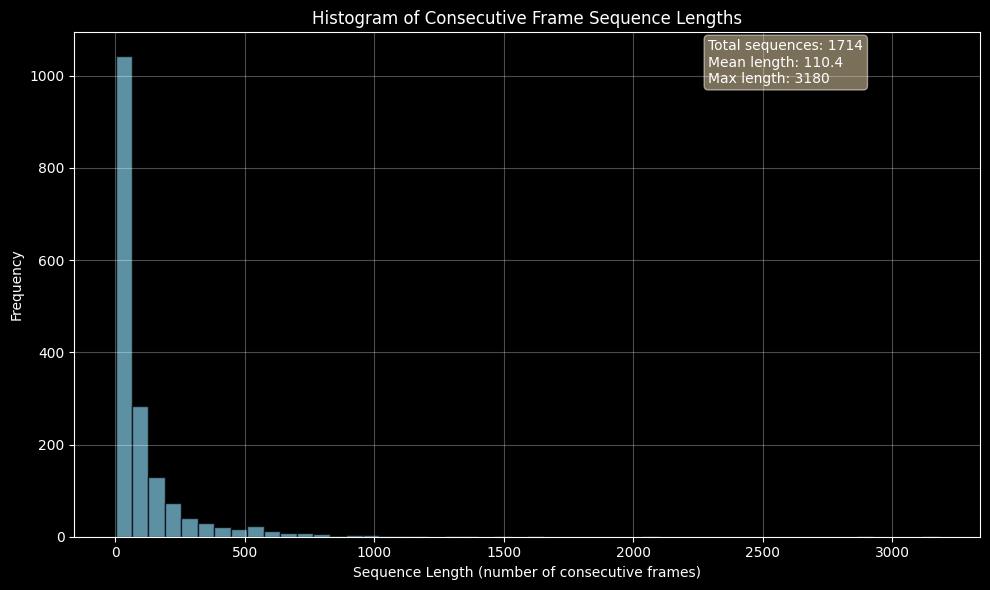

Merged 189269 rows into 1714 sequences
1714

Sequence Summary for track 15 and threshold 0.99:
Total sequences: 1714
Average sequence length: 110.4
Longest sequence: 3180 frames
Average confidence: 0.992
1714
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_15.parquet
Total frames: 108607
Number of unique sequences: 1286
Sequence lengths - Min: 1, Max: 2480, Mean: 84.5


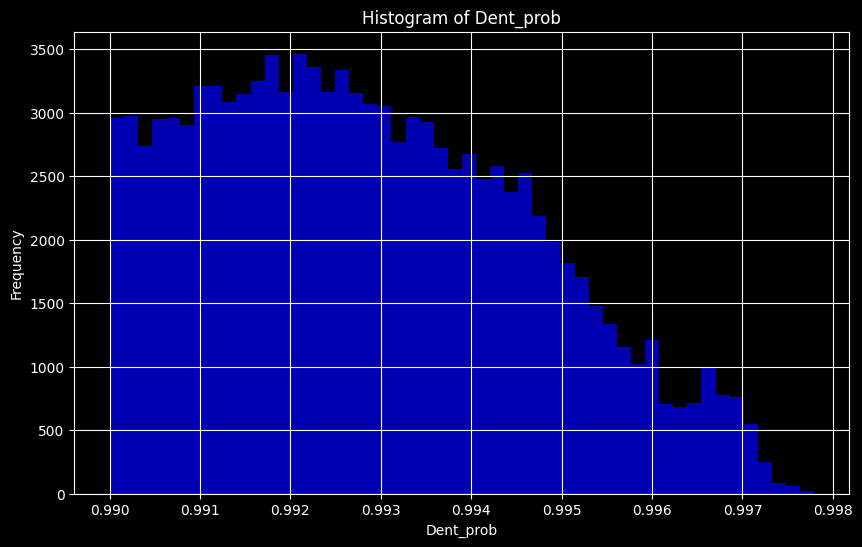

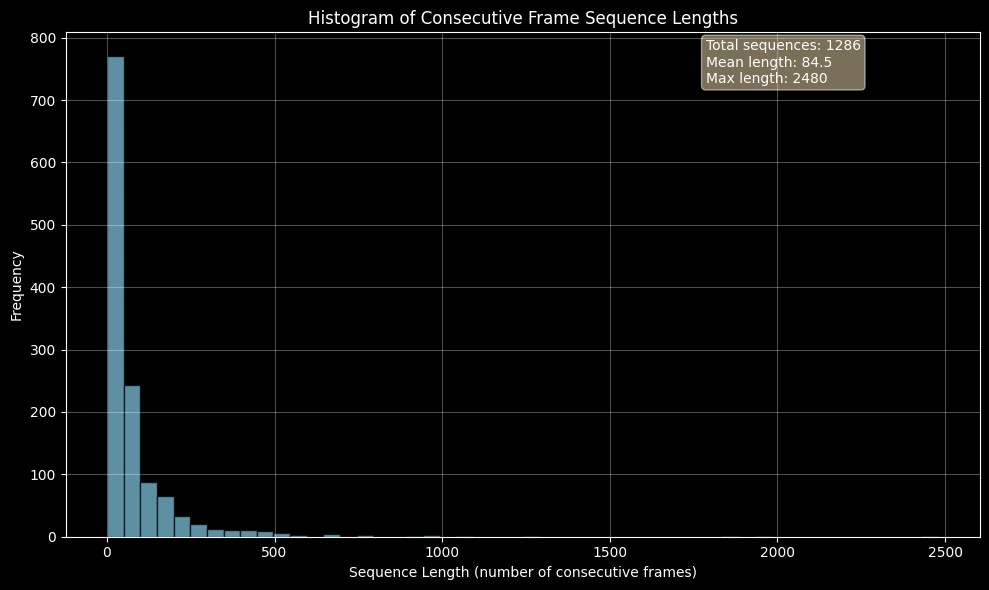

Merged 108607 rows into 1286 sequences
1286

Sequence Summary for track 16 and threshold 0.99:
Total sequences: 1286
Average sequence length: 84.5
Longest sequence: 2480 frames
Average confidence: 0.992
1286
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_16.parquet
Total frames: 128221
Number of unique sequences: 1390
Sequence lengths - Min: 1, Max: 3140, Mean: 92.2


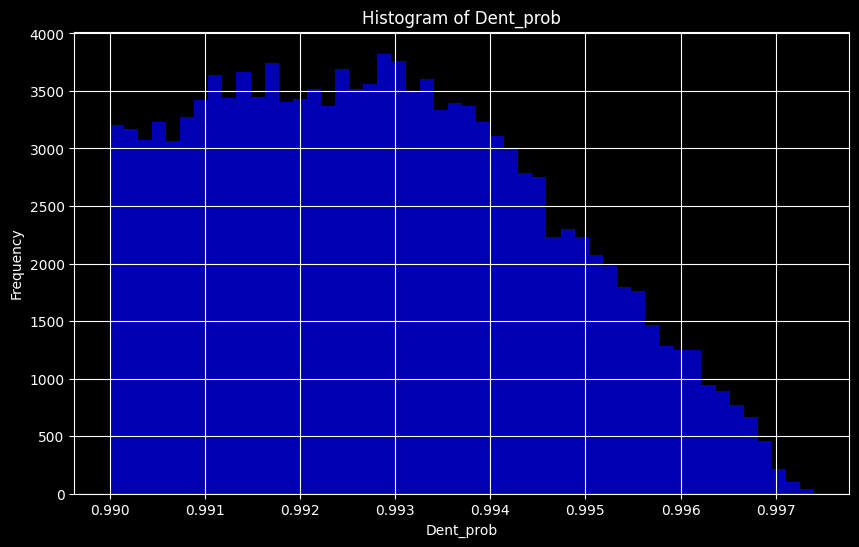

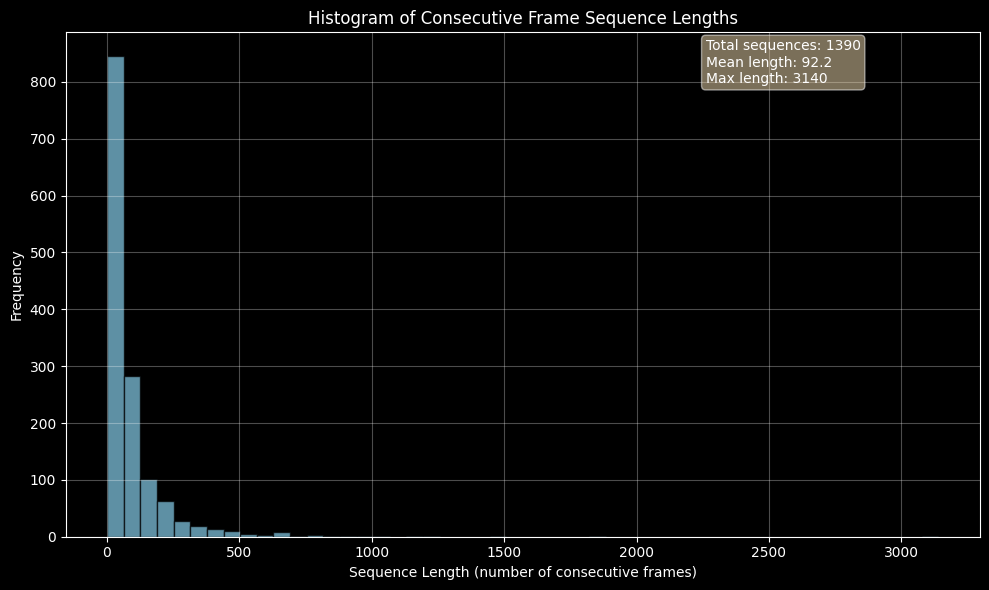

Merged 128221 rows into 1390 sequences
1390

Sequence Summary for track 17 and threshold 0.99:
Total sequences: 1390
Average sequence length: 92.2
Longest sequence: 3140 frames
Average confidence: 0.992
1390
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_17.parquet
Total frames: 200616
Number of unique sequences: 1904
Sequence lengths - Min: 1, Max: 3005, Mean: 105.4


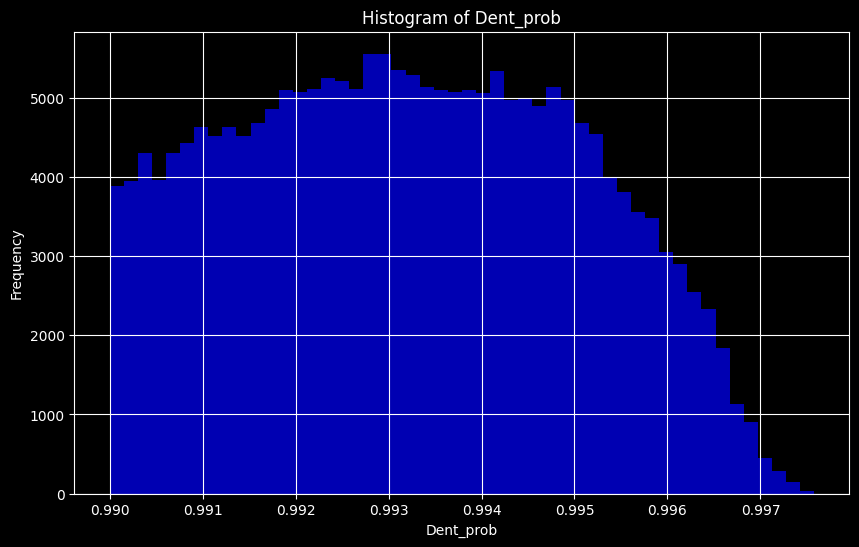

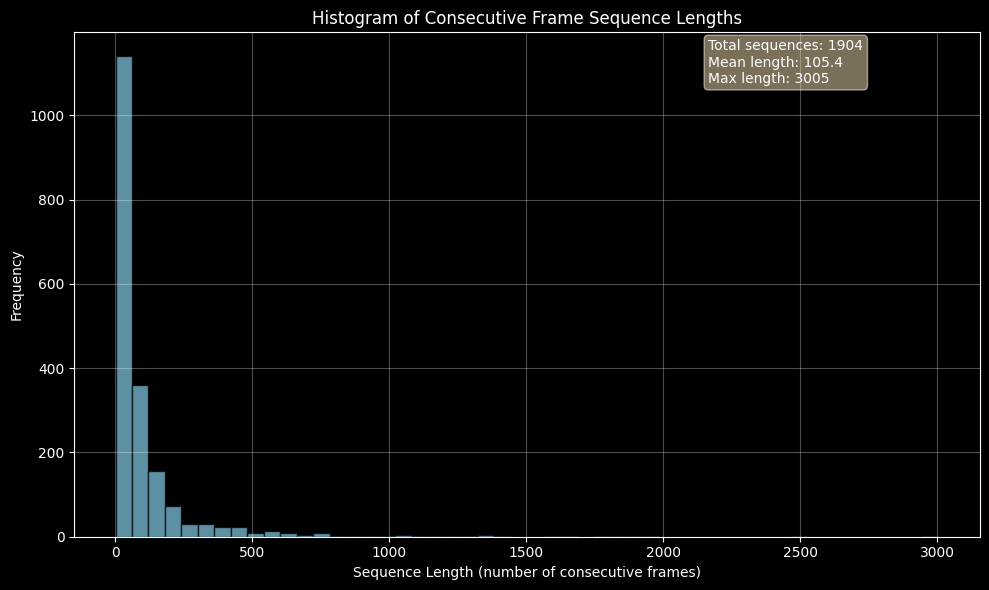

Merged 200616 rows into 1904 sequences
1904

Sequence Summary for track 18 and threshold 0.99:
Total sequences: 1904
Average sequence length: 105.4
Longest sequence: 3005 frames
Average confidence: 0.992
1904
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_18.parquet
Total frames: 3967
Number of unique sequences: 88
Sequence lengths - Min: 1, Max: 1010, Mean: 45.1


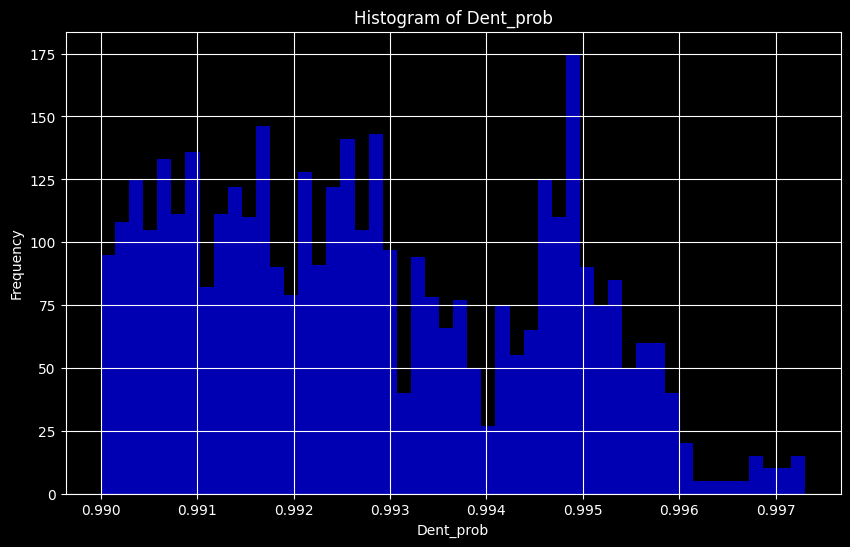

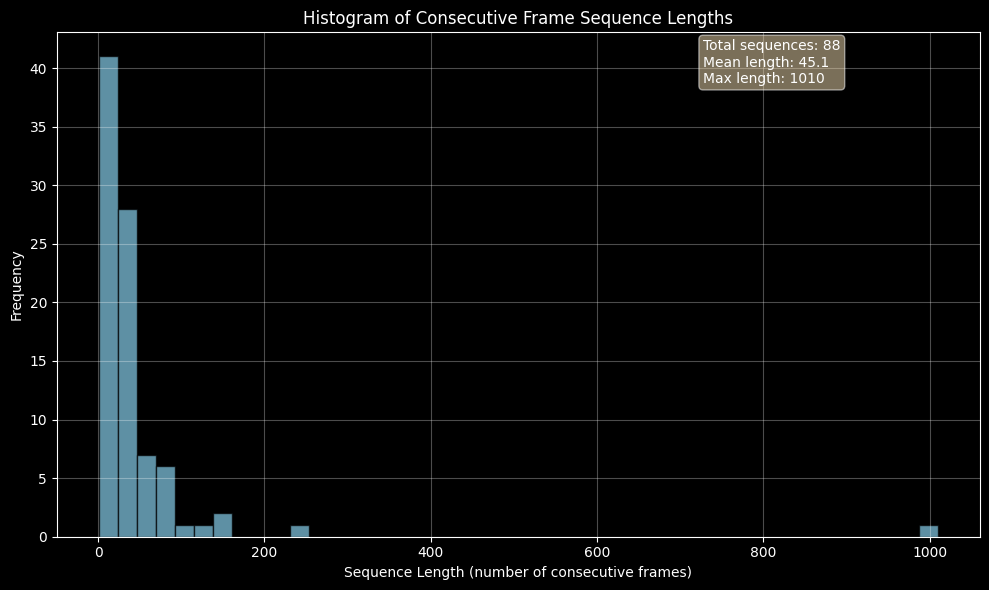

Merged 3967 rows into 88 sequences
88

Sequence Summary for track 19 and threshold 0.99:
Total sequences: 88
Average sequence length: 45.1
Longest sequence: 1010 frames
Average confidence: 0.992
88
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_19.parquet
Total frames: 228224
Number of unique sequences: 2271
Sequence lengths - Min: 1, Max: 5170, Mean: 100.5


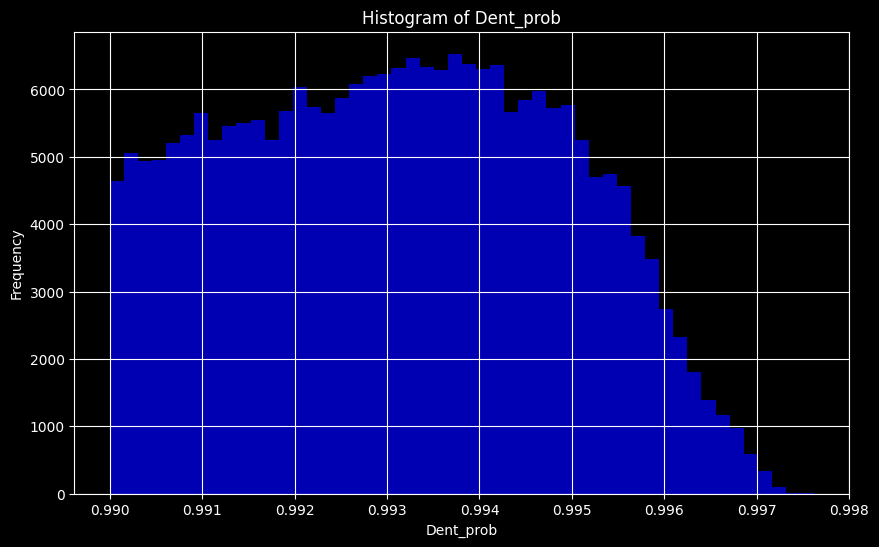

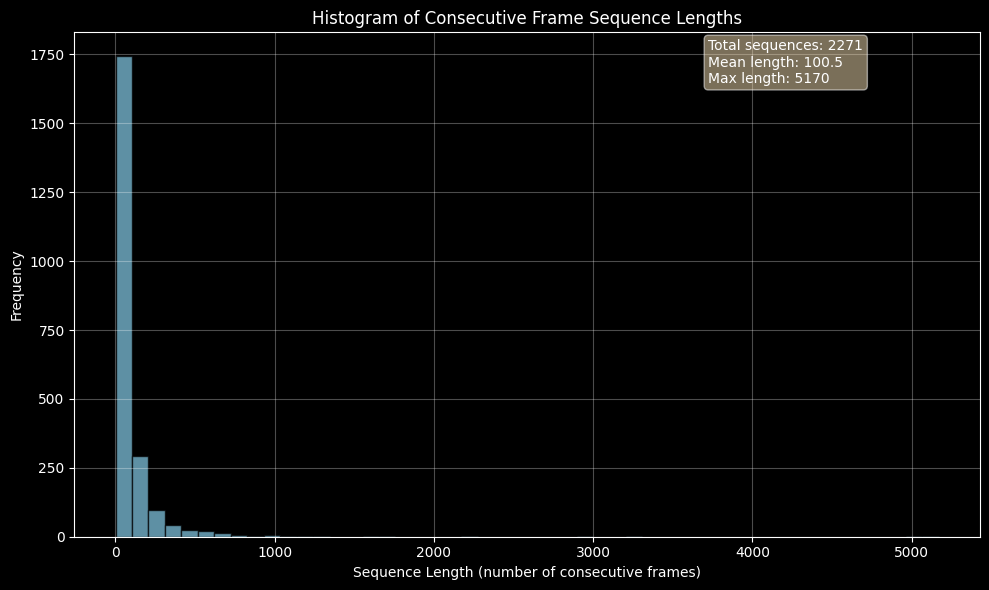

Merged 228224 rows into 2271 sequences
2271

Sequence Summary for track 20 and threshold 0.99:
Total sequences: 2271
Average sequence length: 100.5
Longest sequence: 5170 frames
Average confidence: 0.992
2271
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_20.parquet
Total frames: 126037
Number of unique sequences: 1403
Sequence lengths - Min: 1, Max: 5010, Mean: 89.8


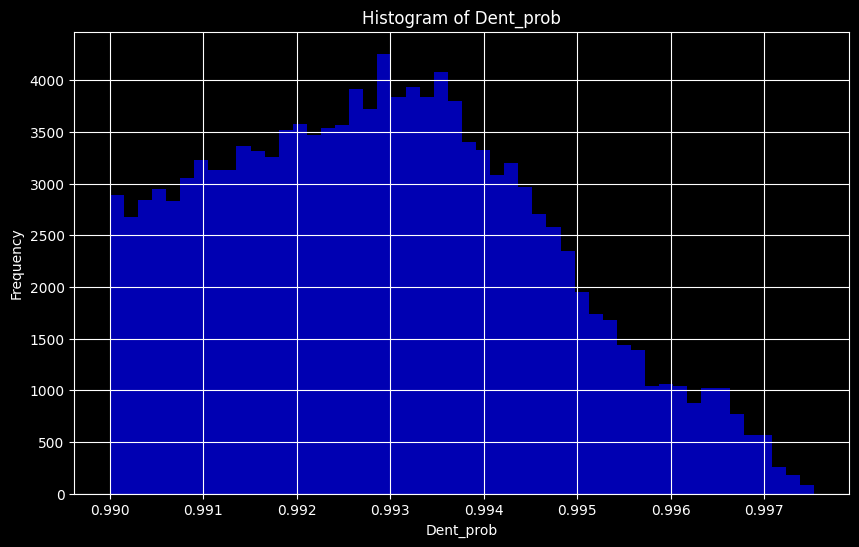

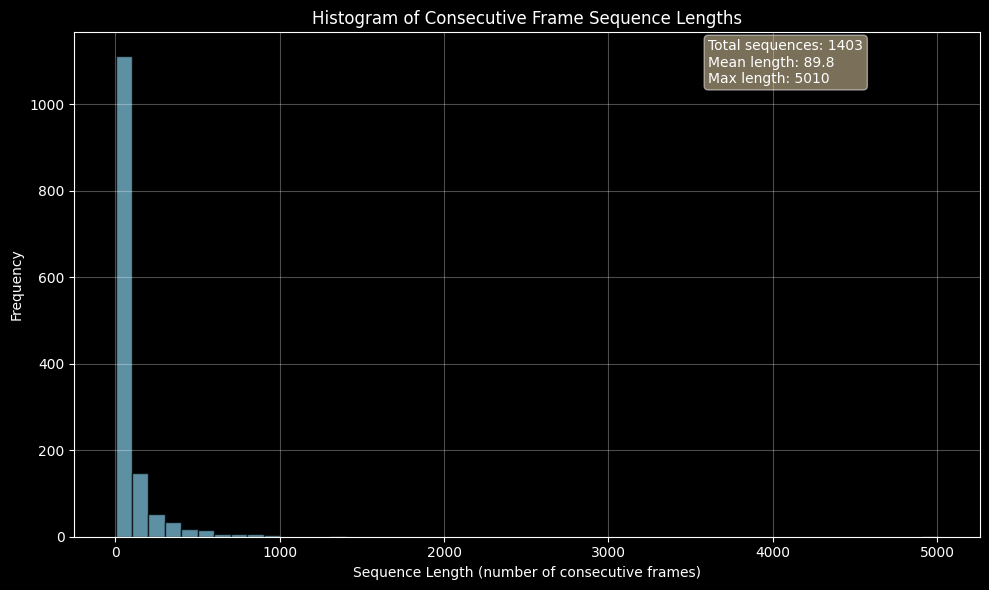

Merged 126037 rows into 1403 sequences
1403

Sequence Summary for track 21 and threshold 0.99:
Total sequences: 1403
Average sequence length: 89.8
Longest sequence: 5010 frames
Average confidence: 0.992
1403
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_21.parquet
Total frames: 93200
Number of unique sequences: 1133
Sequence lengths - Min: 1, Max: 1215, Mean: 82.3


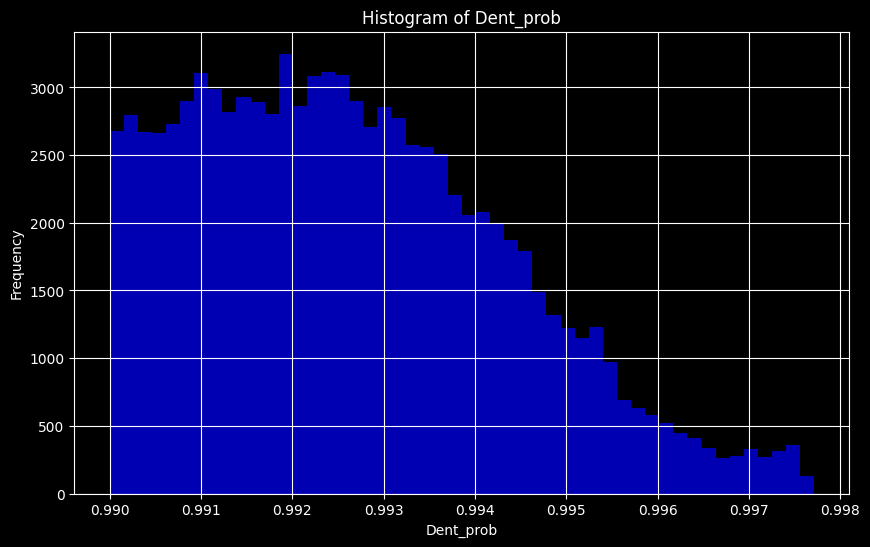

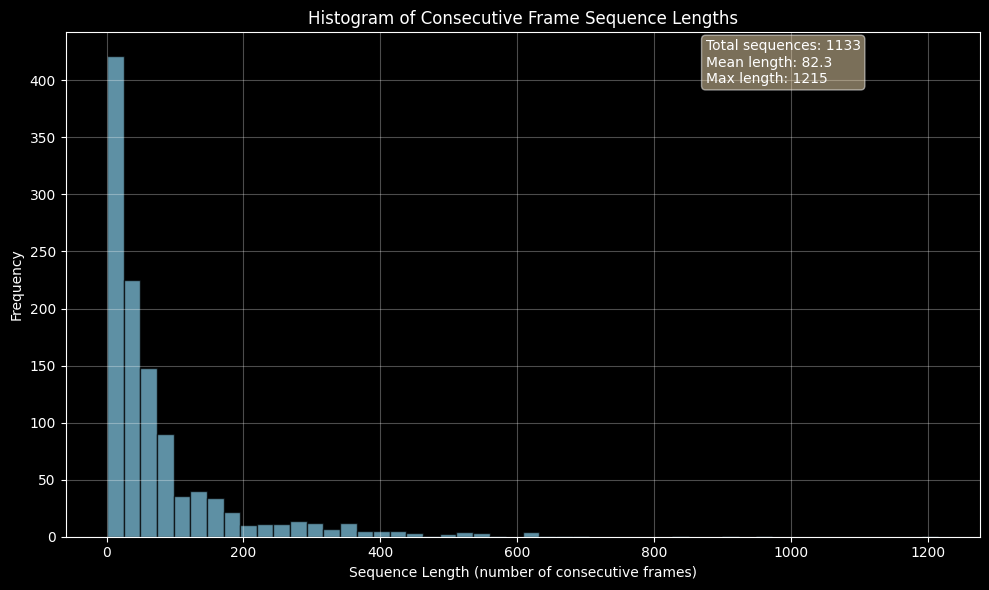

Merged 93200 rows into 1133 sequences
1133

Sequence Summary for track 22 and threshold 0.99:
Total sequences: 1133
Average sequence length: 82.3
Longest sequence: 1215 frames
Average confidence: 0.992
1133
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_22.parquet
Total frames: 79028
Number of unique sequences: 882
Sequence lengths - Min: 1, Max: 1380, Mean: 89.6


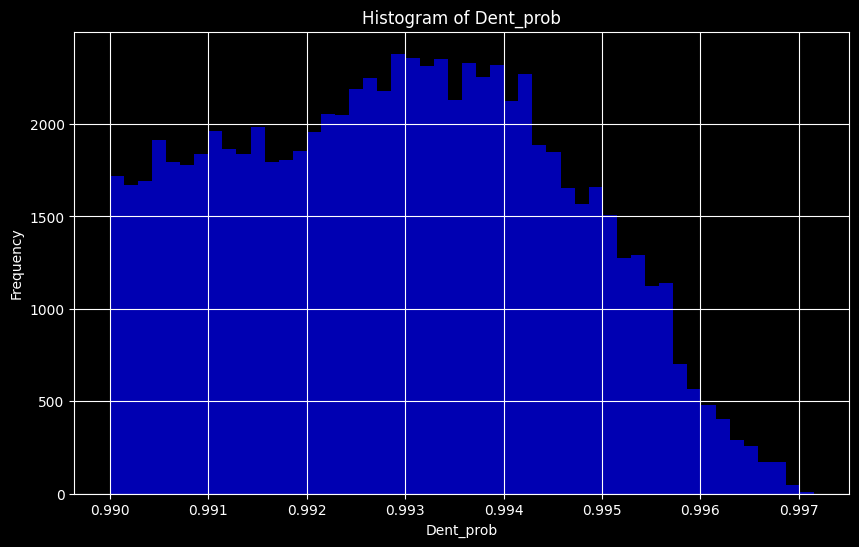

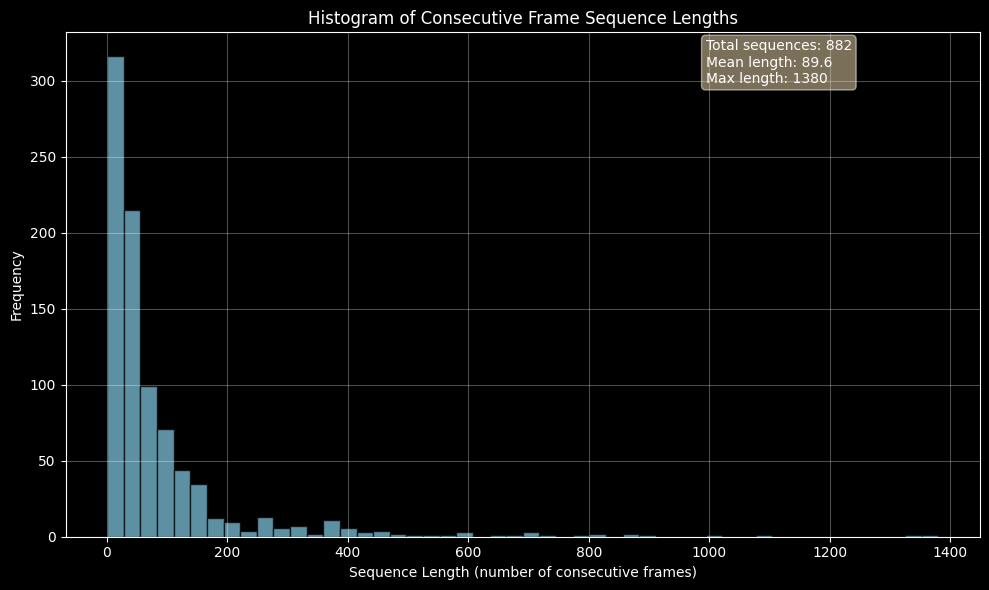

Merged 79028 rows into 882 sequences
882

Sequence Summary for track 23 and threshold 0.99:
Total sequences: 882
Average sequence length: 89.6
Longest sequence: 1380 frames
Average confidence: 0.992
882
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AP3OOMEPID_track_23.parquet


In [9]:
threshold = 0.99
num_tracks = 24
bucket_name = "dent-dev"

for track_idx in range(0, num_tracks):
    s3_key = f"dent_bookmarks/UltrasoundDent_bookmarks_{inspection_id}_track_{track_idx}.parquet"
    filtered_df = create_df(track_idx=track_idx, threshold=threshold)
    if filtered_df.empty:
        print(f"No data for track {track_idx} at threshold {threshold}, skipping.")
        continue
    # Create a histogram of dent_prob
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_df['dent_prob'], bins=50, color='blue', alpha=0.7)
    plt.title('Histogram of Dent_prob')
    plt.xlabel('Dent_prob')
    plt.ylabel('Frequency')
    plt.grid(True)  

    count = len(filtered_df)
    df_with_ranges, num_sequences, seq_lengths = analyze_frame_sequences(filtered_df)


    sequence_df = merge_sequences_to_single_row(df_with_ranges, inspection_id=inspection_id)
    print(len(sequence_df))

    # Optional: Show summary statistics
    print(f"\nSequence Summary for track {track_idx} and threshold {threshold}:")
    print(f"Total sequences: {len(sequence_df)}")
    print(f"Average sequence length: {sequence_df['sequence_length'].mean():.1f}")
    print(f"Longest sequence: {sequence_df['sequence_length'].max()} frames")
    print(f"Average confidence: {sequence_df['avg_confidence'].mean():.3f}")
    print(len(sequence_df))

    save_df_to_s3_parquet(sequence_df, bucket_name, s3_key)
